In [368]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as ma
from scipy.stats import linregress

In [369]:
puntosx=[]
puntosy=[]
T=[-50.0, -48.5, -47.0, -45.5, -44.0, -42.5, -41.0, -39.5, -38.0, -36.5, -35.0, -33.5, -32.0, -30.5, -29.0, -27.5,-26.5,-25,-23.5,-22,-20.5,-19,-17.5,-16,-15,-13,-11.5,-10,-8.5,-7,-5.5,-4,
   -2.5,-1,0.5,1.5,3,4.5,6,7.5,9]
for i in range(0,41):
  data=pd.read_csv('data'+str(1+i*3)+'.csv')
  x=data.iloc[:,0]
  y=data.iloc[:,1]
  ymins=y[-10:]
  ymin=np.mean(ymins)
  y=y-ymin
  ymaxs=y[:5]
  ymax=np.mean(ymaxs)
  y=y/ymax*1.6
  x=x*2500*10**(-9)
  puntosx.append(x)
  puntosy.append(y)
print(T[0],T[6],T[13],T[20],T[27],T[34])

-50.0 -41.0 -30.5 -20.5 -10 0.5


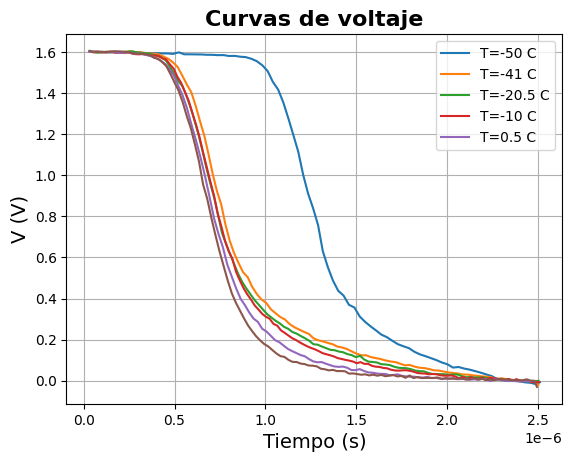

In [370]:
plt.plot(puntosx[0],puntosy[0])
plt.plot(puntosx[6],puntosy[6])
plt.plot(puntosx[13],puntosy[13])
plt.plot(puntosx[20],puntosy[20])
plt.plot(puntosx[27],puntosy[27])
plt.plot(puntosx[34],puntosy[34])
plt.title("Curvas de voltaje",fontsize=16,fontweight='bold')
plt.ylabel("V (V)", fontsize=14)
plt.xlabel("Tiempo (s)", fontsize=14)
plt.legend(['T=-50 C','T=-41 C','T=-20.5 C','T=-10 C','T=0.5 C'])
plt.grid()
plt.show()

In [371]:
xln=[]
yln=[]
for i in range(0,41):
  xL=[]
  yL=[]
  for j in range(0,len(puntosx[i])-1):
    if puntosx[i][j]>0.00 and puntosy[i][j]>0.00:
      xL.append(np.log(puntosx[i][j]))
      yL.append(np.log(puntosy[i][j]))
  xln.append(xL)
  yln.append(yL)

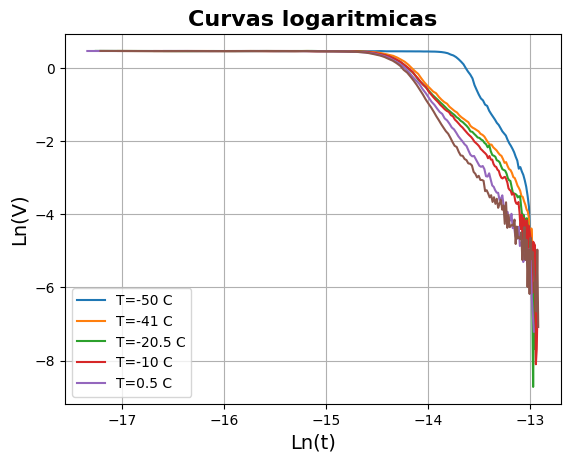

In [372]:
plt.plot(xln[0],yln[0])
plt.plot(xln[6],yln[6])
plt.plot(xln[13],yln[13])
plt.plot(xln[20],yln[20])
plt.plot(xln[27],yln[27])
plt.plot(xln[34],yln[34])
plt.title("Curvas logaritmicas",fontsize=16,fontweight='bold')
plt.ylabel("Ln(V)", fontsize=14)
plt.xlabel("Ln(t)", fontsize=14)
plt.legend(['T=-50 C','T=-41 C','T=-20.5 C','T=-10 C','T=0.5 C'])
plt.grid()
plt.show()

In [373]:
lnxd=[]
lnyd=[]
for i in range(0,41):
  dv=[]
  dt=xln[i][:-1]
  for j in range(0,len(xln[i])-1):
    m=(yln[i][j+1]-yln[i][j])/(xln[i][j+1]-xln[i][j])
    dv.append(m)
  lnxd.append(xln[i])
  lnyd.append(dv)

In [374]:
DT=[]
DV=[]
N=[]
for i in range(0,41):
  temporal1=[]
  temporal2=[]
  temporal3=[]
  for j in range(0,len(lnyd[i])):
    if lnyd[i][j]<-3:
      temporal1.append(lnxd[i][j])
      temporal2.append(lnyd[i][j])
      temporal3.append(j)
  N.append(temporal3)
  DT.append(temporal1)
  DV.append(temporal2)
print(N)

[[36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 70, 71, 72, 73, 75, 76], [39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82], [48, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102], [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98], [50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 86, 87, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112

In [375]:
DDT=[]
DDV=[]
NN=[]
for i in range(0,41):
  temporal1=[]
  temporal2=[]
  temporal3=[]
  j=0
  while True:
    if j >= len(DV[i]) or DV[i][j]<-8: # Added j >= len(DV[i]) to prevent IndexError
      break
    else:
      temporal1.append(DT[i][j]) # Append to temporal1 for x-coordinates
      temporal2.append(DV[i][j]) # Append to temporal2 for y-coordinates
      temporal3.append(N[i][j])
      j+=1
  DDT.append(temporal1)
  DDV.append(temporal2)
  NN.append(temporal3)

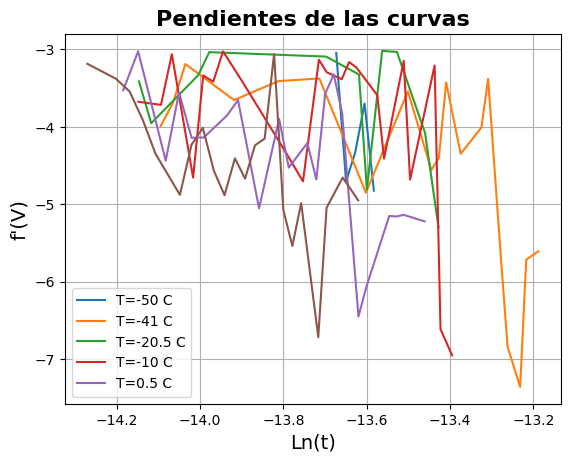

In [376]:
plt.plot(DDT[0],DDV[0])
plt.plot(DDT[6],DDV[6])
plt.plot(DDT[13],DDV[13])
plt.plot(DDT[20],DDV[20])
plt.plot(DDT[27],DDV[27])
plt.plot(DDT[34],DDV[34])
plt.title("Pendientes de las curvas",fontsize=16,fontweight='bold')
plt.ylabel("f'(V)", fontsize=14)
plt.xlabel("Ln(t)", fontsize=14)
plt.legend(['T=-50 C','T=-41 C','T=-20.5 C','T=-10 C','T=0.5 C'])
plt.grid()
plt.show()

In [377]:
LntN=[]
LnVN=[]
m=[]
sigma=[]
for i in range(0,41):
  temporal1=[]
  temporal2=[]
  for j in range(0,len(NN[i])):
    temporal1.append(xln[i][NN[i][j]])
    temporal2.append(yln[i][NN[i][j]])
  LntN.append(temporal1)
  LnVN.append(temporal2)
  slope, intercept, r_value, p_value, std_err = linregress(temporal1, temporal2)
  m.append(-1/slope)
  sigma.append(std_err/slope**2)

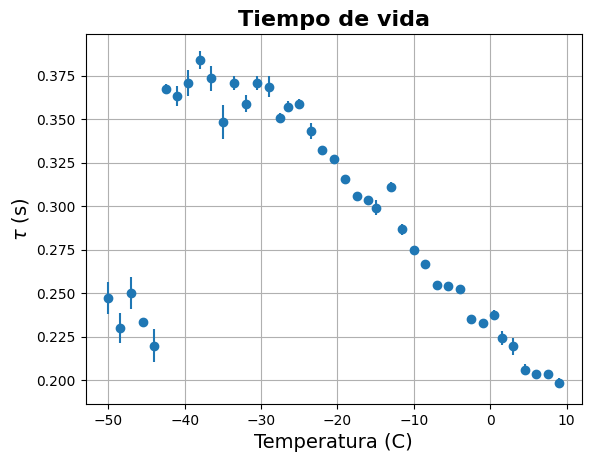

In [378]:
plt.errorbar(T,m,yerr=sigma,fmt='o')
plt.title("Tiempo de vida",fontsize=16,fontweight='bold')
plt.ylabel(r'$\tau$ (s)', fontsize=14)
plt.xlabel("Temperatura (C)", fontsize=14)
plt.grid()
plt.show()

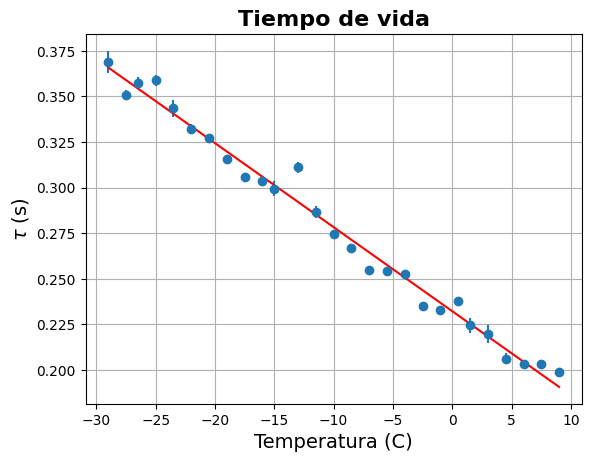

valor de la pendiente:  -0.004608769107614565
Valor de la intercepcion:  0.23220397861680392
Error estandar de la pendiente:  0.00010987961374623248
Valor de r^2:  0.9859887680654021


In [388]:
fittau=[]
fitdtau=[]
fitT=[]
for i in range(0,41):
  if T[i]>-30:
    fittau.append(m[i])
    fitdtau.append(sigma[i])
    fitT.append(T[i])
slope, intercept, r_value, p_value, std_err = linregress( fitT,fittau)
temp=np.linspace(min(fitT),max(fitT))
plt.errorbar(fitT,fittau,yerr=fitdtau,fmt='o')
plt.plot(temp,intercept+slope*temp,'r')
plt.title("Tiempo de vida",fontsize=16,fontweight='bold')
plt.xlabel("Temperatura (C)", fontsize=14)
plt.ylabel(r'$\tau$ (s)', fontsize=14)
plt.grid()
plt.show()
print('valor de la pendiente: ',slope)
print('Valor de la intercepcion: ', intercept)
print('Error estandar de la pendiente: ', std_err)
print('Valor de r^2: ', r_value**2)